## Simple Graph

In [ ]:
from typing import TypedDict

class PortfolioState(TypedDict):
    amount_usd : float
    total_usd: float
    total_npr : float
    

In [5]:
def calc_total(state: PortfolioState) -> PortfolioState:
    state["total_usd"] = state["amount_usd"] * 1.08
    return state

def convert_to_npr(state : PortfolioState) -> PortfolioState:
    state["total_npr"] = state["total_usd"]  * 154
    return state

In [10]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)

builder.add_node("calc_total_node", calc_total)
builder.add_node("convert_to_npr_node", convert_to_npr)

builder.add_edge(START, "calc_total_node")
builder.add_edge("calc_total_node", "convert_to_npr_node")
builder.add_edge("convert_to_npr_node",END)

graph = builder.compile()


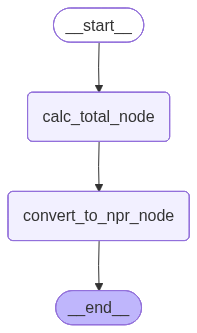

In [12]:
from IPython.display import Image, display

display(
    Image(graph.get_graph().draw_mermaid_png())
)

In [13]:
graph.invoke({'amount_usd':1000})

{'amount_usd': 1000, 'total_usd': 1080.0, 'total_npr': 166320.0}

## Graph With Condition

In [14]:
from typing import TypedDict, Literal

class PortfolioState(TypedDict):
    amount_usd : float
    total_usd : float
    target_currency : Literal["NPR","EUR"]
    total: float

In [17]:
def calc_total(state: PortfolioState) ->PortfolioState:
    state["total_usd"] = state["amount_usd"] * 1.08
    return state

def convert_to_npr(state : PortfolioState) -> PortfolioState:
    state["total"] = state["total_usd"]  * 154
    return state

def convert_to_eur(state: PortfolioState) -> PortfolioState:
    state["total"] = state["total_usd"]  * 0.86
    return state

def choose_conversion(state: PortfolioState) -> str:
    return state["target_currency"]

In [18]:
from langgraph.graph import StateGraph , START, END

builder = StateGraph(PortfolioState)

builder.add_node("calc_total_node",calc_total)
builder.add_node("convert_to_npr_node",convert_to_npr)
builder.add_node("convert_to_eur_node",convert_to_eur)

builder.add_edge(START, "calc_total_node")
builder.add_conditional_edges("calc_total_node",
                              choose_conversion,
                              {
                                  "NPR":"convert_to_npr_node",
                                  "EUR":"convert_to_eur_node"
                              }
)
builder.add_edge(["convert_to_npr_node","convert_to_eur_node"],END)

graph = builder.compile()


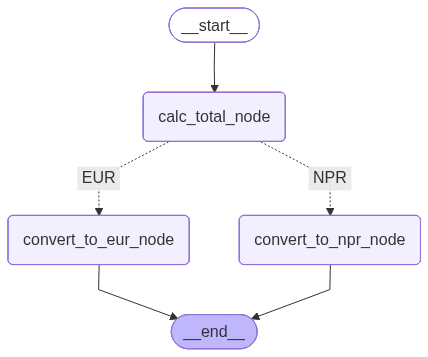

In [19]:
from IPython.display import Image, display

display(
    Image(graph.get_graph().draw_mermaid_png())
)

In [20]:
graph.invoke({"amount_usd":1000, "target_currency":"EUR"})

{'amount_usd': 1000,
 'total_usd': 1080.0,
 'target_currency': 'EUR',
 'total': 928.8}

In [21]:
graph.invoke({"amount_usd":1000, "target_currency":"NPR"})

{'amount_usd': 1000,
 'total_usd': 1080.0,
 'target_currency': 'NPR',
 'total': 166320.0}

## Chatbot

In [75]:
from dotenv import load_dotenv
load_dotenv()

True

In [76]:
import os
from typing_extensions import TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Annotated

API_KEY = os.getenv("GEMINI_API_KEY_LANGGRAPH")

In [77]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [78]:
response = llm.invoke("Are you up? Yes or No.")
print(response.content)

Yes.


In [79]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State) -> State:
    return {"messages": llm.invoke(state["messages"])}

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)

builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node", END)
graph = builder.compile()

In [80]:
messages = [{"role": "user", "content": "Who invented telescope? Give only the name."}]
graph.invoke({"messages": messages})

{'messages': [HumanMessage(content='Who invented telescope? Give only the name.', additional_kwargs={}, response_metadata={}, id='2f53bc4c-ea58-4140-991b-7f0a9d921733'),
  AIMessage(content='Hans Lippershey', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e3f5e-8b3d-7632-9d8e-4653af157eaf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 341, 'total_tokens': 351, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 337}})]}

In [83]:
state = None
while True:
    in_message = input("You: ")
    if in_message.lower() in {"quit", "exit"}:
        break
    
    if state is None:
        state: State = {
            "messages": [{"role": "user", "content": in_message}]
        }
    else:
        state["messages"].append({"role": "user", "content": in_message})

    state = graph.invoke(state)
    print("Bot:", state["messages"][-1].content)

## Chatbot with tool

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START , END
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI

In [ ]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

In [ ]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [ ]:
response = llm.invoke("Are you up? Yes or No.")
print(response.text)

Yes


In [ ]:
#Hardcoded stock prices
@tool
def get_stock_price(symbol : str) -> float:
    """Returns the current stock price for a given ticker symbol."""
    return {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0,
    }.get(symbol, 0.0)

tools = [get_stock_price]

In [ ]:
llm_with_tool = llm.bind_tools(tools)

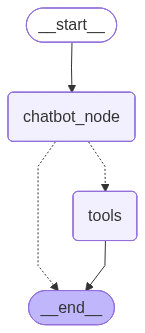

In [ ]:
def chatbot(state: State) -> State:
    return {"messages": llm_with_tool.invoke(state["messages"])}

builder = StateGraph(State)

builder.add_node("chatbot_node", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge("chatbot_node", END)
graph = builder.compile()

from IPython.display import Image, display

display(
    Image(graph.get_graph().draw_mermaid_png())
)

In [ ]:
state = graph.invoke({"messages":[{"role":"user", "content":"What is the price of AMZN stock right now?"}]})
print(state["messages"][-1].content)

150.0


## Tool Call Agent

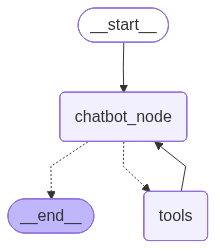

In [ ]:
def chatbot(state: State) -> State:
    return {"messages": llm_with_tool.invoke(state["messages"])}

builder = StateGraph(State)

builder.add_node("chatbot_node", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge("tools", "chatbot_node")
builder.add_edge("chatbot_node", END)
graph = builder.compile()

from IPython.display import Image, display

display(
    Image(graph.get_graph().draw_mermaid_png())
)

In [ ]:
msg = " I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"

In [ ]:
state = graph.invoke({"messages":[{"role":"user", "content":msg}]})
print(state["messages"][-1].content)

[{'type': 'text', 'text': 'The total cost will be $6004.5.', 'extras': {'signature': 'CoIDAQw51segF4iwHYvReB0eSfNXuPMb8mPG6kqCqKmugUSE+iaEPIH0axHrcsi/My8+tUvP7x1BOX1BjE/3mp1Naerw7SNSoSCYLAlJp0qqJVskFdq1/xUQw5l+FIfqkiCzuWqhpWopM64h2IFIixP2+qUdCK1nvQtr1Ra0TMffZLDc6fL5Muy1kFS9baMnvJZrZMimNiC0ypguM6r6HxoEUJzjEX5o7m/K1LcDvUqpEyQNYRoQX1YA1RZqq63u1DQ35XSJRAWfgbLM6Az2Io5PPORiNgn3IIcPJscCtDoZGN4zGvGa2jOT9DS4Ur7F1pRqnpPHcJWo23/o0uz8OIOJAiFm5u8Z9xlrcOQR1c2DYTT/9q1d9NBLE86t2yRkobgvn/g94N3Ryi4RgLjlGX3TJA/Uf+1vQTdUWjZk78HSM43ZOuvzI4kWJf83bKg9rTXYFyLoUtbxqoe4Q6GSdSqrN1AxOq3sYgzwQC20APAeqjLOlGfv/rjx7KinLRpJ7+uH7ok='}}]


## Memory

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

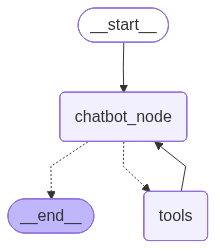

In [ ]:
def chatbot(state: State) -> State:
    return {"messages": llm_with_tool.invoke(state["messages"])}

builder = StateGraph(State)

builder.add_node("chatbot_node", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge("tools", "chatbot_node")
builder.add_edge("chatbot_node", END)
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display

display(
    Image(graph.get_graph().draw_mermaid_png())
)

In [ ]:
config = {'configurable' : {'thread_id':'1'}}

msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"
state = graph.invoke({"messages":[{"role":"user", "content":msg}]}, config=config)
print(state["messages"][-1].content)

[{'type': 'text', 'text': 'The total cost will be $6004.5.', 'extras': {'signature': 'CqsCAQw51seDiAZEVn5E+LPomYjl/ps86Nt4nHUHuTsEgE1dlASbkrIxkQL1gaikAfKrXKDPkKkiw0HvlxnNwznuHUpxAKqWuxi2+y+CPQ3nAwgQL/RnCi5ZZjdzHRGeXnAgUkt1NmPv7HulZcMyo3Q6zo7a0r3LHNf0UJjTrKz3ZHyFC4ItGvTwRk6R9S05NDPazV0f5fqXA1h1H9uOHSrVQFMnBqn5uXJ697bpp7wrb7VY4Wg0syhh142jHJmSXHOpKzUYyN3uKcFYDPKGTGL9YQPq5Xhcza/vyVa6Ju09/UuFL8jCnZp7oIG2W+tupoJWU7sDPhrSkhzl69Su2pqtnH1gvUEIhXAbO32AWZLHW7bURp152u/7sQs5271NGrHTZ32N/T3uecE88wA='}}]


## Monitoring with Langsmith

In [ ]:
config = {'configurable' : {'thread_id':'1'}}
from langsmith import traceable

@traceable
def call_graph(query :str):
    state = graph.invoke(
        {"messages":[{"role":"user", "content": query}]},
        config=config
    )
    return state["messages"][-1].content

call_graph("What is the stock price of AAPL stock right now!")

'The current stock price of AAPL is $100.4.'

In [ ]:
from langsmith import Client

client = Client()
projects = list(client.list_projects())
for p in projects:
    print(p.name)

Fuse
